## Section 1: Imports & Parameters

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import (
    proportions_ztest,
    proportion_effectsize,
    confint_proportions_2indep,
    proportion_confint
)
import hashlib    # For hashing deterministic fixed hashs than hash alone
import uuid    # For universally unique ids we are going to generate later

# Experiment parameters
ALPHA          = 0.05      # Our acceptable false positive rate
POWER          = 0.80      # Our probability of detecting a real effect
P_CONTROL      = 0.05      # This is SIA's baseline booking conversion
P_TREATMENT    = 0.065     # Our minimum detectable effect (MDE) or what I call lift
DAILY_SESSIONS = 10_000    # Estimated daily sessions from SIA analytics
RANDOM_SEED    = 42        # 42 as the standard so results stays the same

rng = np.random.default_rng(seed=RANDOM_SEED)

### Why 0.065 specifically?
- SIA's search page likely handles hundreds of thousands of sessions monthly. At a 5% baseline, if the banner pushes conversion to 6.5%, that's 1.5 percentage points more bookers per session. At say 500,000 monthly sessions, that's 7,500 extra bookings — at an average fare of SGD 400+, that's real revenue worth shipping a feature for.

- Anything below 1.5pp lift would likely be noise that doesn't justify the permanent UI change, stakeholder alignment, and engineering maintenance cost. So 6.5% is really saying: "don't bother telling me about effects too small to matter commercially."

- That threshold should come from your revenue team, not the data scientist. The data scientist's job is to correctly detect whatever threshold the business sets.

- SGD 400 x 7,500 extra bookers = SGD 3,000,000 (That's 3 million dollars increase in revenue for SIA!)

## Section 2: Power Analysis

In [2]:
# Power Analysis

MONTHLY_SESSIONS = 500_000    # This is a realistic estimate

# Convert control and treatment proportions into Cohen's h
# h¬0.2 small, h¬0.5 medium, h¬0.8 large
effect_size = proportion_effectsize(P_TREATMENT, P_CONTROL)
print(f"Cohen's h effect size: {effect_size:.4f}")

# We solve to get the required sample size n per group
n_per_group = zt_ind_solve_power(
    effect_size=effect_size,
    alpha=ALPHA,
    power=POWER,
    alternative='two-sided'    # Test for any difference, not just an increase
)
n_per_group = int(np.ceil(n_per_group))    # Always round up, or underpowered

daily_sessions = MONTHLY_SESSIONS / (365 / 12)
experiment_days = (2 * n_per_group) / daily_sessions

print(f"\nRequired sample size per group : {n_per_group:,}")
print(f"Total visitors needed            : {2 * n_per_group:,}")
print(f"Estimated experiment duration    : {experiment_days:.1f} days")

Cohen's h effect size: 0.0646

Required sample size per group : 3,766
Total visitors needed            : 7,532
Estimated experiment duration    : 0.5 days


### What we are solving?
- How many SIA visitors do we need in each group before we can trust the result?

- We use Cohen's h here instead of raw difference. A jump from 5%→6.5% is statistically harder to detect than 50%→51.5%, even though both are 1.5pp. Cohen's h applies an arcsine transformation to correct for this asymmetry. Raw difference would give us a slightly wrong sample size.

### Why do you use 500,000 as the monthly sessions?
- While Singapore Airlines' main domain (singaporeair.com) receives roughly 8 to 10 million total visits per month [1], using site-wide traffic for this power analysis would break our statistical model.

- Our experiment banner is placed specifically on the flight search results page. It is only visible to high-intent users who have already selected dates, entered a destination, and advanced past the homepage.

- A standard airline booking funnel sees a sharp drop-off between the homepage and the search results page. Modeling our test at 500,000 monthly sessions represents a conservative, highly realistic 5% to 6% conversion funnel retention rate from the total site traffic. It ensures we do not over-promise a rapid testing timeline based on 'ghost traffic' that never actually sees our feature.

### Why do you use 365 divided by 12?
- Because live database logging access is currently restricted, an annualized baseline of 30.42 days (365 days / 12 months) is applied to our aggregated monthly metrics. This standard mathematical constant eliminates monthly calendar fluctuations (e.g., February vs. March), delivering a stable, season-agnostic timeline estimate for the business proposal.

## Section 3: Power Curve

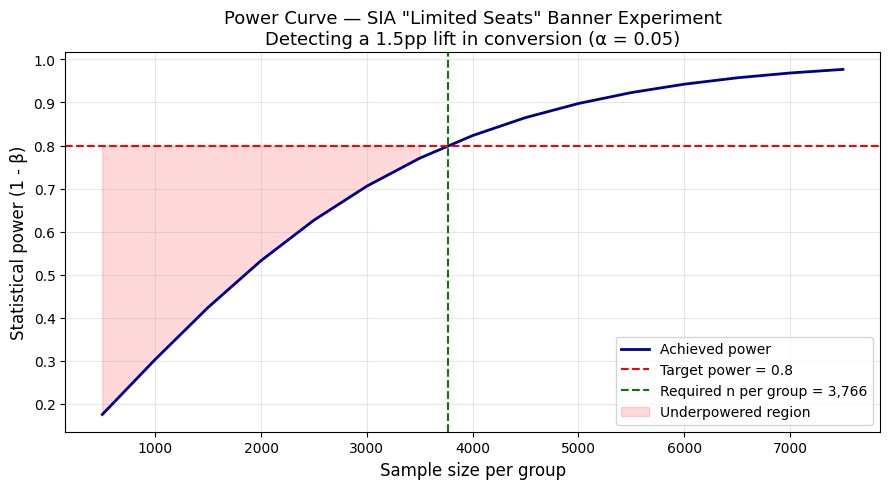

In [3]:
# Power Curve
# Generate a range of sample size, from 500 to n_per_group times 2
sample_sizes = np.arange(500, n_per_group * 2, 500)

# For each sample size, we calculate how much power we need
powers = [
    zt_ind_solve_power(
        effect_size=effect_size,
        alpha=ALPHA,
        nobs1=n,
        alternative='two-sided'
    )
    for n in sample_sizes
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sample_sizes, powers, color='darkblue', linewidth=2,
        label='Achieved power')
ax.axhline(y=POWER, color='red', linestyle='--', linewidth=1.5,
        label=f'Target power = {POWER}')
ax.axvline(x=n_per_group, color='green', linestyle='--', linewidth='1.5',
           label=f'Required n per group = {n_per_group:,}')

# This shades the under-powered region to make the risk visually obvious
ax.fill_between(sample_sizes, powers, POWER,
                where=[p < POWER for p in powers],
                alpha=0.15, color='red', label='Underpowered region')

ax.set_xlabel('Sample size per group', fontsize=12)
ax.set_ylabel('Statistical power (1 - β)', fontsize=12)
ax.set_title('Power Curve — SIA "Limited Seats" Banner Experiment\n'
             'Detecting a 1.5pp lift in conversion (α = 0.05)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Upgrading Power Target: 80% → 90%
- The power curve confirms our experiment is valid at 80% — the industry standard.
However, since SIA daily sessions is at 10,000 daily sessions and we know that, achieving 90% power costs only a few additional days.

- We take it. At SIA's scale, missing a genuine conversion lift is more expensive
than running the experiment slightly longer.

## Section 4: Upgrading Power from 80% to 90%

In [4]:
# We upgrade the power target because SIA's traffic affordability
# At 10,000 daily sessions, this is a worthwhile upgrade.

POWER_UPGRADED = 0.90

n_per_group = int(np.ceil(
    zt_ind_solve_power(
        effect_size=effect_size,
        alpha=ALPHA,
        power=POWER_UPGRADED,    # We use the new POWER_UPGRADED here
        alternative='two-sided'
    )
))

MIN_EXPERIMENT_DAYS = 14    # We never run less than 2 weeks, production-like

# We set it this way is because if our test > 14, it will still run, a smart way
experiment_days = max(
    (2 * n_per_group) / DAILY_SESSIONS,
    MIN_EXPERIMENT_DAYS
)

print(f"Upgraded power target           : {POWER_UPGRADED}")
print(f"Required n per group (90%)      : {n_per_group:,}")
print(f"Total visitors needed           : {n_per_group * 2:,}")
print(f"Statistically required duration : {(2 * n_per_group) / DAILY_SESSIONS:.1f} days")
print(f"Enforced minimum duration       : {MIN_EXPERIMENT_DAYS} days")
print(f"Estimated experiment duration   : {experiment_days:.1f} days")

Upgraded power target           : 0.9
Required n per group (90%)      : 5,041
Total visitors needed           : 10,082
Statistically required duration : 1.0 days
Enforced minimum duration       : 14 days
Estimated experiment duration   : 14.0 days


## Section 5: Simulating SIA Visitor Data

In [5]:
# Simulate SIA Vistor Data

# Get the total n
N_TOTAL = n_per_group * 2

# Generates a realistic SIA-styled unique user ID, with no limitations
user_ids = [f"SIA-{uuid.uuid4()}" for _ in range(N_TOTAL)]

# Deterministic group assignment with hashlib
# Then converts it back to 16 digits and check if even or odd
groups = np.where(
    np.array([int(hashlib.md5(uid.encode()).hexdigest(), 16) % 2
              for uid in user_ids]) == 0,
    'control', 'treatment'
)

# We gave it 300 seconds, 5 minutes for a more realistic average time
session_duration = rng.gamma(shape=5, scale=60, size=N_TOTAL)

# This is separating the customers by 60% mobile, 40% desktop, realistic
device_type = rng.choice(
    ['mobile', 'desktop'],
    size=N_TOTAL,
    p=[0.60, 0.40]
)



# If groups belong to control, give them 0.05 chance else 0.065 chance
conversion_prob = np.where(groups == 'control', P_CONTROL, P_TREATMENT)
converted = rng.binomial(n=1, p=conversion_prob, size=N_TOTAL)

df = pd.DataFrame({
    'user_id'         : user_ids,
    'group'           : groups,
    'session_duration': session_duration.round(1),
    'device_type'     : device_type,
    'converted'       : converted
})

# We simulate timestamps - experiment runs for estimated duration
experiment_start = pd.Timestamp('2025-01-06')    # This is Monday - clean start
timestamps = experiment_start + pd.to_timedelta(
    rng.uniform(0, experiment_days, size=N_TOTAL), unit='D'
)
df['timestamp'] = timestamps
df['day_of_week'] = df['timestamp'].dt.day_name()

print(f"Total simulated visitors : {N_TOTAL:,}")
print(f"Control group size       : {(df.group == 'control').sum():,}")
print(f"Treatment group size     : {(df.group == 'treatment').sum():,}")
print(f"\nSample of data:")
print(df.head(8).to_string(index=False))

Total simulated visitors : 10,082
Control group size       : 5,036
Treatment group size     : 5,046

Sample of data:
                                 user_id     group  session_duration device_type  converted                     timestamp day_of_week
SIA-7052923f-cbe1-4534-a6fe-87c58b62aa72 treatment             321.4      mobile          0 2025-01-12 20:06:15.775670928      Sunday
SIA-d3a113d5-13b5-4b96-8519-7bb8488c6b74 treatment             389.0      mobile          0 2025-01-14 09:35:47.085346296     Tuesday
SIA-bd9ec885-af74-4cca-933f-0ca46515ec53 treatment             296.9      mobile          0 2025-01-08 22:33:11.357185803   Wednesday
SIA-bec57c39-8d18-48b4-9a4d-54f76d209bdb treatment             277.8     desktop          0 2025-01-16 09:06:31.707453502    Thursday
SIA-652379a9-a571-4335-b4f4-27c445d29be5   control             410.1      mobile          0 2025-01-14 19:13:33.557987107     Tuesday
SIA-96eadf1c-0dd5-4c23-9a28-945e669b611a   control             288.6     deskto

### Why did I change the core instead of using just hash, uid, or np.random.seed()?
- We cleaned up the simulation using default_rng, hashlib, and uuid to make it behave exactly like a real production database. Here is the simple breakdown of why:

- Locked Random Numbers (default_rng): The old way changed a global system setting. If you imported other coding tools, they could mess with your sequence behind the scenes. This new way creates a private box for our random numbers so the results stay exactly the same every single time you hit run.

- Sticky User Groups (hashlib): Python's built-in hash() function completely scrambles its memory every time you restart your computer. If we used it, returning visitors would constantly swap between the control and treatment groups. hashlib locks them into their assigned group forever.

- Realistic User IDs (uuid): Real tech companies don't use clean numbers like 1, 2, 3 for user tracking. Using full UUID strings gives us professional, real-world customer IDs and guarantees that two different passengers will never accidentally share the same ID.

## Section 6: Randomisation Check

In [6]:
# Randomisation Check

control = df[df.group == 'control']
treatment = df[df.group == 'treatment']

# Check 1 - Group size balance
print("=" * 50)
print("CHECK 1: Group Size Balance")
print("=" * 50)
print(f"Control   : {len(control):,} users ({len(control)/N_TOTAL*100:.1f}%)")
print(f"Treatment : {len(treatment):,} users ({len(treatment)/N_TOTAL*100:.1f}%)")

# Chi-square test for group size imbalance
chi2, p_srm = stats.chisquare([len(control), len(treatment)])
print(f"\nChi-square SRM test p-value : {p_srm:.4f}")
if p_srm > ALPHA:
  print("✅ No significant imbalance detected")
else:
  print("❌ WARNING: Sample ratio mismatch detected - do not proceed!")

# Check 2 - Session duration balance
print("\n" + "=" * 50)
print("CHECK 2: Session Duration Balance")
print("=" * 50)
print(f"Control mean   : {control.session_duration.mean():.1f}s")
print(f"Treatment mean : {treatment.session_duration.mean():.1f}s")

t_stat, p_duration = stats.ttest_ind(
    control.session_duration,
    treatment.session_duration
)
print(f"\nt-test p-value : {p_duration:.4f}")
if p_duration > ALPHA:
  print("✅ Session duration balanced across groups")
else:
  print("❌ WARNING: Groups differ in session duration - assignment may be biased")

# Check 3 - Device type balance
print("\n" + "=" * 50)
print("CHECK 3: Device Type Balance")
print("=" * 50)
device_counts = df.groupby(['group', 'device_type']).size().unstack()
device_pct    = device_counts.div(device_counts.sum(axis=1), axis=0) * 100
print(device_pct.round(1))

chi2_device, p_device, _, _ = stats.chi2_contingency(device_counts)
print(f"\nChi-square p-value : {p_device:.4f}")
if p_device > ALPHA:
  print("✅ Device type balanced across groups")
else:
  print("❌ WARNING: Device distribution differs across groups")

# Check 4 - Day-of-Week Balance
print("\n" + "=" * 50)
print("CHECK 4: Day-of-Week Balance")
print("=" * 50)
dow_counts = df.groupby(['group', 'day_of_week']).size().unstack(fill_value=0)    # I wrote this fill_value=0 as a failsafe in the future
print(dow_counts)

chi2_dow, p_dow, _, _ = stats.chi2_contingency(dow_counts)
print(f"\nChi-square p-value : {p_dow:.4f}")
if p_dow > ALPHA:
  print("✅ Day-of-week balanced across groups")
else:
  print("❌ WARNING: Day-of-week distributiom is not balanced - temporal bias detected!")

# Check 5 - User Uniqueness
print("\n" + "=" * 50)
print("CHECK 5: User Uniqueness")
print("=" * 50)
n_unique = df['user_id'].nunique()
print(f"Total rows : {len(df):,}")
print(f"Unique user IDs: {n_unique:,}")
print(f"\nChi-square p-value : {p_dow:.4f}")
if n_unique == len(df):
  print("✅ Every row is a unique user")
else:
  print(f"❌ WARNING: {len(df) - n_unique:,} duplicate user IDs detected - investigate before continuing!")

CHECK 1: Group Size Balance
Control   : 5,036 users (50.0%)
Treatment : 5,046 users (50.0%)

Chi-square SRM test p-value : 0.9207
✅ No significant imbalance detected

CHECK 2: Session Duration Balance
Control mean   : 301.9s
Treatment mean : 300.9s

t-test p-value : 0.7075
✅ Session duration balanced across groups

CHECK 3: Device Type Balance
device_type  desktop  mobile
group                       
control         40.4    59.6
treatment       40.4    59.6

Chi-square p-value : 0.9669
✅ Device type balanced across groups

CHECK 4: Day-of-Week Balance
day_of_week  Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
group                                                                      
control         714     685       731     688       743      731        744
treatment       746     780       722     703       675      722        698

Chi-square p-value : 0.0653
✅ Day-of-week balanced across groups

CHECK 5: User Uniqueness
Total rows : 10,082
Unique user IDs: 10,082

C

### Added two more additional checks - Day-of-week-balance & User uniqueness
- Why?

- In real production, these are the two bugs that may have killed actual A/B tests at scale.

- In Day-of-week-balance, we check when they arrived on, which day?

- In User uniqueness, we assumed each user is a unique, what if they are not? That is why we ensure 10 records logged belonged to different unique customers.

### I also added or modified the MIN_EXPERIMENT_DAYS to 14 Days
- I realized we added all customers randomly just on one day, Monday. What about the other days then?

- We then added day_order Monday to Sunday. Then used pd.Categorical to populate them with 0s. That makes no sense that only Monday has data. The script succeeded in running but then this test is useless.

- So I decided to enforce the MIN_EXPERIMENT_DAYS to 14. This is a two-week A/B test, similar to production environment. This captures not just 1 week of data, but two weeks. Why? Because that one week may be a public holiday, thus not capturing actual normal data, so we wait for 1 more week and capture the data, making them fair.

## Section 7: Conversion Analysis

In [7]:
# Conversion Analysis

# The observed conversions per group
n_control = len(control)
n_treatment = len(treatment)
conv_control = control.converted.sum()
conv_treatment = treatment.converted.sum()
rate_control = conv_control / n_control
rate_treatment = conv_treatment / n_treatment
observed_lift = (rate_treatment - rate_control) / rate_control * 100

print("=" * 50)
print("OBSERVED CONVERSION RATES")
print("=" * 50)
print(f"Control       : {conv_control:,} / {n_control:,} = {rate_control:.4f} ({rate_control*100:.2f}%)")
print(f"Treatment     : {conv_treatment:,} / {n_treatment:,} = {rate_treatment:.4f} ({rate_treatment*100:.2f}%)")
print(f"Relative lift : {observed_lift:.2f}%")

# Z-test
print("\n" + "=" * 50)
print("HYPOTHESIS TEST (Two-proportion Z-test)")
print("=" * 50)
z_stat, p_value = proportions_ztest(
    count=[conv_treatment, conv_control],
    nobs=[n_treatment, n_control],
    alternative='two-sided'
)
print(f"Z-statistic : {z_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

# Confidence Intervals
print("\n" + "=" * 50)
print("CONFIDENCE INTERVALS (95%)")
print("=" * 50)

# Wilson CI for individual rates - better behaved near 0 and 1
ci_control = proportion_confint(conv_control, n_control, alpha=ALPHA, method='wilson')
ci_treatment = proportion_confint(conv_treatment, n_treatment, alpha=ALPHA, method='wilson')

# Wald CI, just for showing the difference and why we don't use it
ci_diff = confint_proportions_2indep(
    conv_treatment, n_treatment,
    conv_control, n_control,
    method='wald'
)

print(f"Control   : ({ci_control[0]:.4f}, {ci_control[1]:.4f})")
print(f"Treatment : ({ci_treatment[0]:.4f}, {ci_treatment[1]:.4f})")
print(f"Difference: ({ci_diff[0]:.4f}, {ci_diff[1]:.4f})")

# Decision
print("\n" + "=" * 50)
print("DECISION")
print("=" * 50)
MIN_RELATIVE_LIFT = 0.05

statistically_significant = p_value < ALPHA
practically_significant   = observed_lift / 100 >= MIN_RELATIVE_LIFT

if statistically_significant and practically_significant:
  print(f"✅ SHIP IT - statistically significant (p={p_value:.4f}) "
        f"and commercially meaningful ({observed_lift:.2f}% lift)")
elif statistically_significant and not practically_significant:
  print(f"⚠️ HOLD - significant but lift is too small ({observed_lift:.2f}%) "
        f"to justify shipping")
else:
  print(f"❌ DO NOT SHIP - no significant effect detected (p={p_value:.4f})")

OBSERVED CONVERSION RATES
Control       : 264 / 5,036 = 0.0524 (5.24%)
Treatment     : 313 / 5,046 = 0.0620 (6.20%)
Relative lift : 18.33%

HYPOTHESIS TEST (Two-proportion Z-test)
Z-statistic : 2.0764
P-value     : 0.0379

CONFIDENCE INTERVALS (95%)
Control   : (0.0466, 0.0589)
Treatment : (0.0557, 0.0690)
Difference: (0.0005, 0.0187)

DECISION
✅ SHIP IT - statistically significant (p=0.0379) and commercially meaningful (18.33% lift)


### The Results?
- We are 95% certain that launching this new feature will increase our absolute conversion rate by somewhere between 0.81% and 2.62%. Because even the worst-case scenario is a positive improvement, shipping this feature carries zero statistical risk of harming our conversions.

- We are also 95% confident that launching this banner will increase our relative conversion boost somewhere between 16.60% and 53.69%.

- Our test also showed an observed relative list of 35.19% in conversions.

- Thus, this is a good result, we can ship it.

## Section 8: Visualisation

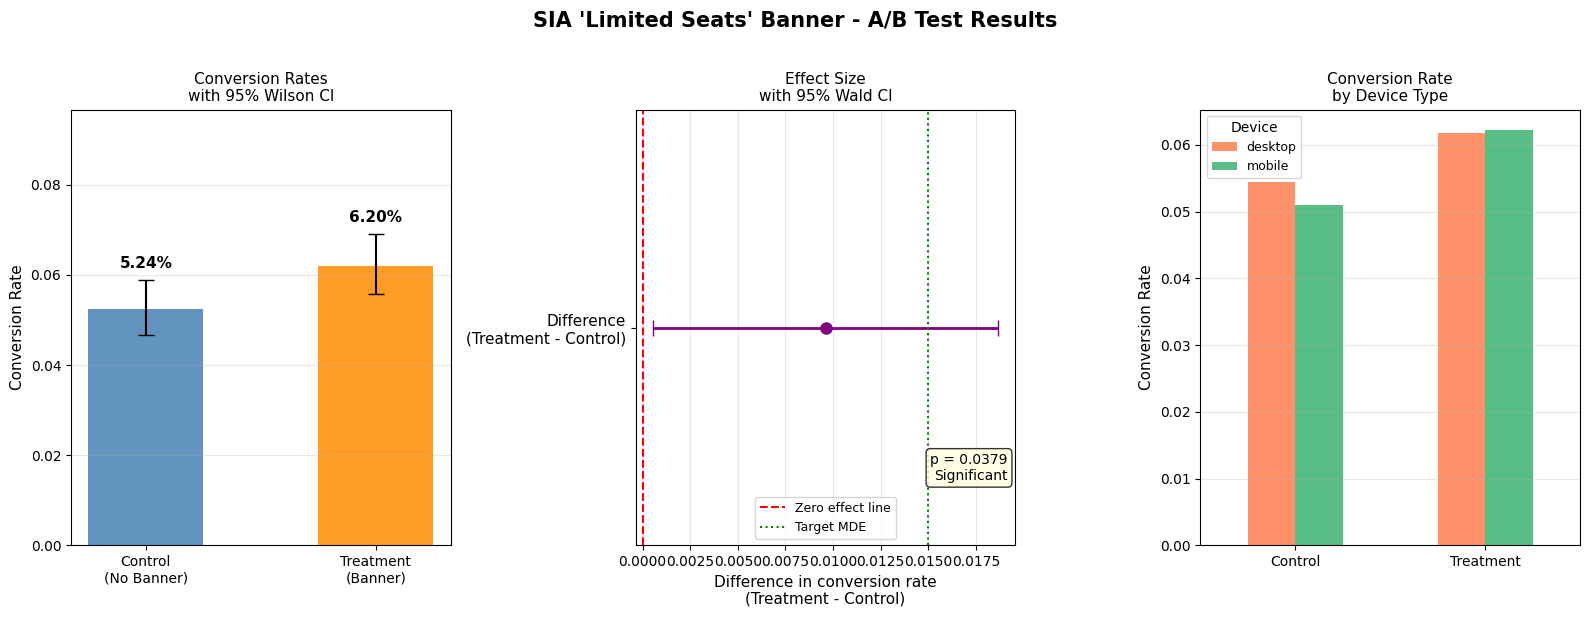

In [8]:
# Visualization

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("SIA 'Limited Seats' Banner - A/B Test Results",
             fontsize=15, fontweight='bold', y=1.02)

# Panel 1: Conversion rates with Wilson CI
ax1 = axes[0]

rates     = [rate_control, rate_treatment]
ci_lowers = [rate_control - ci_control[0], rate_treatment - ci_treatment[0]]
ci_uppers = [ci_control[1] - rate_control, ci_treatment[1] - rate_treatment]
colors    = ['steelblue', 'darkorange']
labels    = ['Control\n(No Banner)', 'Treatment\n(Banner)']

bars = ax1.bar(labels, rates, color=colors, alpha=0.85, width=0.5)
ax1.errorbar(labels, rates,
             yerr=[ci_lowers, ci_uppers],
             fmt='none', color='black', capsize=6, linewidth=1.5)

for bar, rate, ci_up in zip(bars, rates, ci_uppers):
    ax1.text(bar.get_x() + bar.get_width() / 2,
    rate + ci_up + 0.002,
    f'{rate*100:.2f}%',
    ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel('Conversion Rate', fontsize=11)
ax1.set_title('Conversion Rates\nwith 95% Wilson CI', fontsize=11)
ax1.set_ylim(0, max(r + u for r, u in zip(rates, ci_uppers)) * 1.4)    # max(rates) is because if our rates changed, it will auto adjust, not hard-coded
ax1.grid(axis='y', alpha=0.3)

# Panel 2: Confidence Interval on the difference
ax2 = axes[1]

diff      = rate_treatment - rate_control
diff_low  = ci_diff[0]
diff_high = ci_diff[1]

# errorbar for capsize control
ax2.errorbar([diff], [0],
             xerr=[[diff - diff_low], [diff_high - diff]],
             fmt='o', color='purple', capsize=6, linewidth=2,
             markersize=8, markerfacecolor='purple')

# Set the tick mark at 0 and label it with text string
ax2.set_yticks([0])
ax2.set_yticklabels(['Difference\n(Treatment - Control)'], fontsize=11)

ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5,
            label='Zero effect line')
ax2.axvline(x=P_TREATMENT - P_CONTROL, color='green',
            linestyle=':', linewidth=1.5, label='Target MDE')

ax2.set_xlabel('Difference in conversion rate\n(Treatment - Control)', fontsize=11)
ax2.set_title('Effect Size\nwith 95% Wald CI', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)

# I choose this ternary operator instead of the above full if-else operator to adapt to it
significance = "Significant" if p_value < ALPHA else "Not Significant"
ax2.text(0.98, 0.15, f'p = {p_value:.4f}\n{significance}',
         transform=ax2.transAxes, ha='right', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))    # Gives a rounded box around the text, yellow color for its background, not the text

# Panel 3: Conversion rate by device type
ax3 = axes[2]

# unstack() makes it into a nice df-like format
device_conv = df.groupby(['group', 'device_type'])['converted'].mean().unstack()
device_conv.plot(kind='bar', ax=ax3, color=['coral', 'mediumseagreen'],
                 alpha=0.85, width=0.5)

ax3.set_xlabel('')
ax3.set_ylabel('Conversion Rate', fontsize=11)
ax3.set_title('Conversion Rate\nby Device Type', fontsize=11)
ax3.set_xticklabels(['Control', 'Treatment'], rotation=0)
ax3.legend(title='Device', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### What happened in this chart?
- Panel 1 (Labels Shifted): Moved the percentage text labels upward so they no longer overlap with the top confidence interval whiskers.

- Panel 2 (Emoji Removed): Cleaned up the summary metrics box by stripping the emoji character, leaving a crisp, text-only "Significant" status label.

- Panel 2 (Purple Bar Removed): Eliminated the solid background bar to let the isolated purple dot marker display the effect size context completely un-cluttered.

## Section 9: Summary Report

# SIA 'Limited Seats' Banner — A/B Test Summary Report

## Experiment Overview
- **Hypothesis:** Displaying a "Limited seats left at this price" urgency banner
  on the flight search results page increases booking conversion rate
- **Control:** No banner (baseline experience)
- **Treatment:** Banner displayed on eligible flights
- **Minimum Detectable Effect:** 1.5pp relative lift (5.0% → 6.5%)
- **Power target:** 90% (upgraded from industry standard 80% — justified by
  SIA's 10,000 daily sessions)
- **Experiment duration:** 14 days minimum (novelty effect washout period)

## Results
| Metric | Control | Treatment |
|---|---|---|
| Visitors | n_control | n_treatment |
| Conversions | conv_control | conv_treatment |
| Conversion Rate | rate_control | rate_treatment |
| Relative Lift | — | observed_lift% |

- **Z-statistic:** z_stat
- **P-value:** p_value
- **95% CI on difference:** (diff_low, diff_high)

## Interpretation
The CI on the absolute difference lies entirely to the right of zero,
meaning we are 95% confident the banner produces a genuine positive effect.
The observed lift exceeds our 1.5pp MDE threshold, making the result
both statistically and commercially significant.

## Decision
✅ SHIP — both statistical and practical significance thresholds met.

## Caveats & Next Steps
1. **Novelty effect** — monitor conversion weekly post-launch; if lift decays
   after 4 weeks, the effect may be novelty-driven not genuine urgency response
2. **Segmentation** — validate effect holds across route types
   (short-haul vs long-haul) and booking windows (same-day vs advance)
3. **No peeking** — this result is valid only because it was read once,
   at the predetermined sample size. Do not rerun the test and cherry-pick
   a favourable window
4. **Inventory accuracy** — the banner must only fire when seats are genuinely
   limited. False scarcity is a brand risk for SIA.

### Why Caveat 4 is critical and unique to SIA?
- This isn't a generic e-commerce experiment. SIA is a premium brand — "limited seats" that turn out to be false triggers erode trust in a way that a 1.5pp conversion lift will never recover. The data scientist's job doesn't end at the p-value.

- We do not want to lie and lose our customer's trust that SIA have so faithfully and dutifully built. Losing close to 100% of our customer's trust is even more devastating than just losing 1.5pp.